<a href="https://colab.research.google.com/github/Vitelmojr01/REPOSITORIO-04/blob/modulo-regressaoI-tarefa-03/tarefa_03_mod12_resolvendo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regressão 01 - tarefa 03 - transformações em X e Y

Carregue os pacotes necessários e a base de gorjetas.

### I. Modelo no valor da gorjeta

1. Crie a matriz de design (e a matriz y) utilizando o Patsy, para um modelo em ```tip```, explicada por ```sex, smoker, diner e net_bill```.  
2. Remova as variáveis não significantes.  
3. observe o gráfico de resíduos em função de ```net_bill```  
4. teste transformar ```net_bill``` no log e um polinômio. Escolha o melhor modelo.

Resolvendo tarefa 03 - Exercicio 01 - item 1
1, Crie a matriz de design (e a matriz y) utilizando o Patsy, para um modelo em tip, explicada por sex, smoker, diner e net_bill.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

print("Carregando a base...")
gorjetas = sns.load_dataset('tips')

gorjetas['net_bill'] = gorjetas['total_bill'] - gorjetas['tip']
gorjetas['diner'] = gorjetas['time']

print(gorjetas.head())

print("\nModelo inicial")
modelo1 = smf.ols('tip ~ sex + smoker + diner + net_bill', data=gorjetas).fit()
print(modelo1.summary())

Carregando a base...
   total_bill   tip     sex smoker  day    time  size  net_bill   diner
0       16.99  1.01  Female     No  Sun  Dinner     2     15.98  Dinner
1       10.34  1.66    Male     No  Sun  Dinner     3      8.68  Dinner
2       21.01  3.50    Male     No  Sun  Dinner     3     17.51  Dinner
3       23.68  3.31    Male     No  Sun  Dinner     2     20.37  Dinner
4       24.59  3.61  Female     No  Sun  Dinner     4     20.98  Dinner

Modelo inicial
                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.324
Method:                 Least Squares   F-statistic:                     30.13
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           2.64e-20
Time:                        11:32:46   Log-Likelihood:                -375.13
No. Observations:                 244   AIC:             

Resolvendo tarefa 03 - Exercicio 01 - item 2
 2.Remova as variáveis não significantes.

In [ ]:
print("\nVerificando significância das variáveis...")
print(modelo1.pvalues)

print("\nModelo reduzido")
modelo2 = smf.ols('tip ~ net_bill + diner', data=gorjetas).fit()
print(modelo2.summary())


Verificando significância das variáveis...
Intercept          1.389032e-06
sex[T.Female]      9.824382e-01
smoker[T.No]       3.523485e-01
diner[T.Dinner]    7.287609e-01
net_bill           5.764964e-22
dtype: float64

Modelo reduzido
                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.333
Model:                            OLS   Adj. R-squared:                  0.327
Method:                 Least Squares   F-statistic:                     60.11
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           6.62e-22
Time:                        11:59:06   Log-Likelihood:                -375.58
No. Observations:                 244   AIC:                             757.2
Df Residuals:                     241   BIC:                             767.6
Df Model:                           2                                         
Covariance Type:            nonrobust                

Resolvendo tarefa 03 - Exercicio 01 - item 3

 3.observe o gráfico de resíduos em função de net_bill


Analisando resíduos do modelo reduzido...


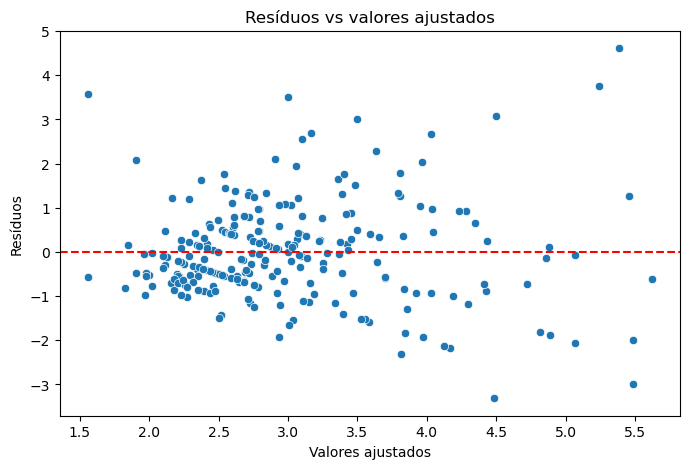

In [ ]:
print("\nAnalisando resíduos do modelo reduzido...")

plt.figure(figsize=(8,5))
sns.scatterplot(x=modelo2.fittedvalues, y=modelo2.resid)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores ajustados')
plt.ylabel('Resíduos')
plt.title('Resíduos vs valores ajustados')
plt.show()

Resolvendo tarefa 03 - Exercicio 01 - item 4

4.teste transformar net_bill no log e um polinômio. Escolha o melhor modelo.

In [ ]:
print("\nModelo com log(net_bill)")
modelo_log = smf.ols('tip ~ diner + np.log(net_bill)', data=gorjetas).fit()
print(modelo_log.summary())

print("\nModelo com polinômio de 2º grau")
modelo_poly = smf.ols('tip ~ diner + net_bill + I(net_bill**2)', data=gorjetas).fit()
print(modelo_poly.summary())

print("\nComparando R²")
print("Modelo reduzido :", modelo2.rsquared)
print("Modelo log      :", modelo_log.rsquared)
print("Modelo polinômio:", modelo_poly.rsquared)


Modelo com log(net_bill)
                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.295
Model:                            OLS   Adj. R-squared:                  0.289
Method:                 Least Squares   F-statistic:                     50.47
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           4.90e-19
Time:                        12:20:32   Log-Likelihood:                -382.27
No. Observations:                 244   AIC:                             770.5
Df Residuals:                     241   BIC:                             781.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept     

### II. Modelo no valor do percentual da gorjeta

1. Crie a matriz de design (e a matriz y) utilizando o Patsy, para um modelo no log de ```tip```, explicado por ```sex, smoker, diner e net_bill```.
2. Remova as variáveis não significantes.
3. Observe o gráfico de resíduos em função de ```net_bill```
4. Teste transformar ```net_bill``` no log e um polinômio. Escolha o melhor modelo.
5. Do modelo final deste item, calcule o $R^2$ na escala de ```tip``` (sem o log). Compare com o modelo do item 1. Qual tem melhor coeficiente de determinação?

Resolvendo tarefa 03 - Exercicio 02 - item 1
 1.Crie a matriz de design (e a matriz y) utilizando o Patsy, para um modelo no log de tip, explicado por sex, smoker, diner e net_bill.

In [ ]:
print("\nCriando tip_pct...")
gorjetas['tip_pct'] = gorjetas['tip']/gorjetas['net_bill']

print(gorjetas[['tip','net_bill','tip_pct']].head())

print("\nModelo log(tip_pct)")
modelo_pct1 = smf.ols('np.log(tip_pct) ~ sex + smoker + diner + np.log(net_bill)',
                      data=gorjetas).fit()

print(modelo_pct1.summary())


Criando tip_pct...
    tip  net_bill   tip_pct
0  1.01     15.98  0.063204
1  1.66      8.68  0.191244
2  3.50     17.51  0.199886
3  3.31     20.37  0.162494
4  3.61     20.98  0.172069

Modelo log(tip_pct)
                            OLS Regression Results                            
Dep. Variable:        np.log(tip_pct)   R-squared:                       0.294
Model:                            OLS   Adj. R-squared:                  0.282
Method:                 Least Squares   F-statistic:                     24.92
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           2.94e-17
Time:                        12:38:14   Log-Likelihood:                -96.213
No. Observations:                 244   AIC:                             202.4
Df Residuals:                     239   BIC:                             219.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
 

Resolvendo tarefa 03 - Exercicio 02 - item 2
2.Remova as variáveis não significantes.

In [ ]:
print("\nVerificando p-values")
print(modelo_pct1.pvalues)

print("\nModelo reduzido tip_pct")
modelo_pct2 = smf.ols('np.log(tip_pct) ~ np.log(net_bill)',
                      data=gorjetas).fit()

print(modelo_pct2.summary())


Verificando p-values
Intercept           4.328949e-03
sex[T.Female]       8.698638e-01
smoker[T.No]        7.334319e-01
diner[T.Dinner]     6.798956e-01
np.log(net_bill)    3.246754e-19
dtype: float64

Modelo reduzido tip_pct
                            OLS Regression Results                            
Dep. Variable:        np.log(tip_pct)   R-squared:                       0.293
Model:                            OLS   Adj. R-squared:                  0.291
Method:                 Least Squares   F-statistic:                     100.5
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           5.20e-20
Time:                        12:42:38   Log-Likelihood:                -96.357
No. Observations:                 244   AIC:                             196.7
Df Residuals:                     242   BIC:                             203.7
Df Model:                           1                                         
Covariance Type:            nonrobust                         

Resolvendo tarefa 03 - Exercicio 02 - item 3
 3.Observe o gráfico de resíduos em função de net_bill

In [ ]:
print("\nCalculando R² no tip_pct original")

pred = np.exp(modelo_pct2.fittedvalues)

cor = np.corrcoef(gorjetas['tip_pct'], pred)[0,1]

print("R²:", cor**2)


Calculando R² no tip_pct original
R²: 0.30894874740322265


Resolvendo tarefa 03 - Exercicio 02 - item 4
 4.Teste transformar net_bill no log e um polinômio. Escolha o melhor modelo

In [ ]:
print("\nTestando modelo com log(net_bill)")
modelo_log = smf.ols('tip ~ diner + np.log(net_bill)',
                     data=gorjetas).fit()

print(modelo_log.summary())

print("\nTestando modelo polinomial")
modelo_poly = smf.ols('tip ~ diner + net_bill + I(net_bill**2)',
                      data=gorjetas).fit()

print(modelo_poly.summary())

print("\nComparação dos R²:")

print("Modelo reduzido:", modelo2.rsquared)
print("Modelo log:", modelo_log.rsquared)
print("Modelo polinomial:", modelo_poly.rsquared)

print("\nMelhor modelo é o de maior R²")


Testando modelo com log(net_bill)
                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.295
Model:                            OLS   Adj. R-squared:                  0.289
Method:                 Least Squares   F-statistic:                     50.47
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           4.90e-19
Time:                        12:58:48   Log-Likelihood:                -382.27
No. Observations:                 244   AIC:                             770.5
Df Residuals:                     241   BIC:                             781.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Inter

### III. Previsão de renda

Vamos trabalhar a base que você vai usar no projeto do final deste ciclo.

Carregue a base ```previsao_de_renda.csv```.

|variavel|descrição|
|-|-|
|data_ref                | Data de referência de coleta das variáveis |
|index                   | Código de identificação do cliente|
|sexo                    | Sexo do cliente|
|posse_de_veiculo        | Indica se o cliente possui veículo|
|posse_de_imovel         | Indica se o cliente possui imóvel|
|qtd_filhos              | Quantidade de filhos do cliente|
|tipo_renda              | Tipo de renda do cliente|
|educacao                | Grau de instrução do cliente|
|estado_civil            | Estado civil do cliente|
|tipo_residencia         | Tipo de residência do cliente (própria, alugada etc)|
|idade                   | Idade do cliente|
|tempo_emprego           | Tempo no emprego atual|
|qt_pessoas_residencia   | Quantidade de pessoas que moram na residência|
|renda                   | Renda em reais|

1. Ajuste um modelo de regressão linear simples para explicar ```renda``` como variável resposta, por ```tempo_emprego``` como variável explicativa. Observe que há muitas observações nessa tabela. Utilize os recursos que achar necessário.
2. Faça uma análise de resíduos. Com os recursos vistos neste módulo, como você melhoraria esta regressão?
3. Ajuste um modelo de regressão linear múltipla para explicar ```renda``` (ou uma transformação de ```renda```) de acordo com as demais variáveis.
4. Remova as variáveis não significantes e ajuste novamente o modelo. Interprete os parâmetros
5. Faça uma análise de resíduos. Avalie a qualidade do ajuste.

Resolvendo tarefa 03 - Exercicio 03 - item 1
 1.Ajuste um modelo de regressão linear simples para explicar renda como variável resposta, por tempo_emprego como variável explicativa. Observe que há muitas observações nessa tabela. Utilize os recursos que achar necessário.

In [ ]:
print("Carregando base de renda...")

renda = pd.read_csv('previsao_de_renda.csv')

print(renda.head())

print("\nModelo simples renda ~ tempo_emprego")

modelo_renda1 = smf.ols('renda ~ tempo_emprego', data=renda).fit()

print(modelo_renda1.summary())

Carregando base de renda...
   Unnamed: 0    data_ref  index sexo  posse_de_veiculo  posse_de_imovel  \
0           0  2015-01-01   8682    F             False             True   
1           1  2015-01-01  12830    M              True             True   
2           2  2015-01-01   2885    M              True             True   
3           3  2015-01-01  16168    F              True            False   
4           4  2015-01-01  12438    M             False            False   

   qtd_filhos   tipo_renda           educacao estado_civil tipo_residencia  \
0           1  Assalariado         Secundário       Casado            Casa   
1           0   Empresário         Secundário       Casado            Casa   
2           2  Assalariado  Superior completo       Casado            Casa   
3           0   Empresário         Secundário       Casado            Casa   
4           0  Assalariado         Secundário       Casado            Casa   

   idade  tempo_emprego  qt_pessoas_residencia

Resolvendo tarefa 03 - Exercicio 03 - item 2
2.Faça uma análise de resíduos. Com os recursos vistos neste módulo, como você melhoraria esta regressão?


Analisando resíduos


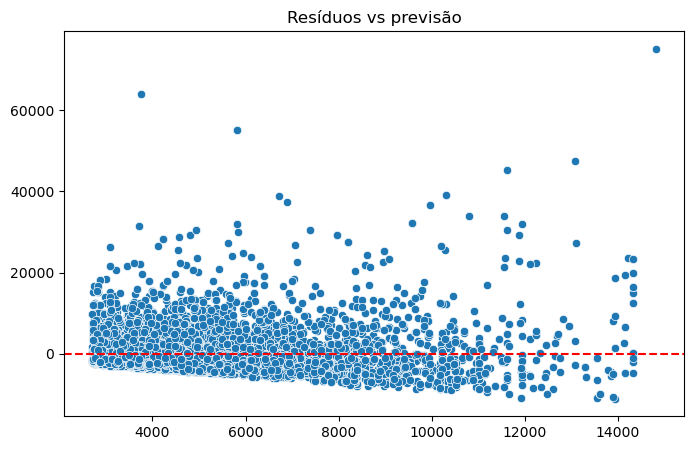

In [ ]:
print("\nAnalisando resíduos")

plt.figure(figsize=(8,5))

sns.scatterplot(x=modelo_renda1.fittedvalues,
                y=modelo_renda1.resid)

plt.axhline(0,color='red',linestyle='--')

plt.title("Resíduos vs previsão")

plt.show()

Resolvendo tarefa 03 - Exercicio 03 - item 3
3.Ajuste um modelo de regressão linear múltipla para explicar renda (ou uma transformação de renda) de acordo com as demais variáveis.

In [ ]:
print("\nModelo múltiplo")

modelo_renda2 = smf.ols('renda ~ idade + tempo_emprego + educacao + qt_pessoas_residencia',
                        data=renda).fit()

print(modelo_renda2.summary())


Modelo múltiplo
                            OLS Regression Results                            
Dep. Variable:                  renda   R-squared:                       0.161
Model:                            OLS   Adj. R-squared:                  0.160
Method:                 Least Squares   F-statistic:                     340.4
Date:                Thu, 02 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:02:58   Log-Likelihood:            -1.2245e+05
No. Observations:               12466   AIC:                         2.449e+05
Df Residuals:                   12458   BIC:                         2.450e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------

Resolvendo tarefa 03 - Exercicio 03 - item 4
Remova as variáveis não significantes e ajuste novamente o modelo. Interprete os parâmetros

In [ ]:
print("\nP-values:")
print(modelo_renda2.pvalues)

print("\nModelo final")

modelo_renda3 = smf.ols('renda ~ tempo_emprego + idade',
                        data=renda).fit()

print(modelo_renda3.summary())


P-values:
Intercept                          0.000635
educacao[T.Pós graduação]          0.072361
educacao[T.Secundário]             0.401611
educacao[T.Superior completo]      0.653881
educacao[T.Superior incompleto]    0.344849
idade                              0.000025
tempo_emprego                      0.000000
qt_pessoas_residencia              0.000480
dtype: float64

Modelo final
                            OLS Regression Results                            
Dep. Variable:                  renda   R-squared:                       0.156
Model:                            OLS   Adj. R-squared:                  0.156
Method:                 Least Squares   F-statistic:                     1152.
Date:                Thu, 02 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:05:15   Log-Likelihood:            -1.2249e+05
No. Observations:               12466   AIC:                         2.450e+05
Df Residuals:                   12463   BIC:           

Resolvendo tarefa 03 - Exercicio 03 - item 5
5.Faça uma análise de resíduos. Avalie a qualidade do ajuste.
5.1 Gráfico para a analise


Resíduos modelo final


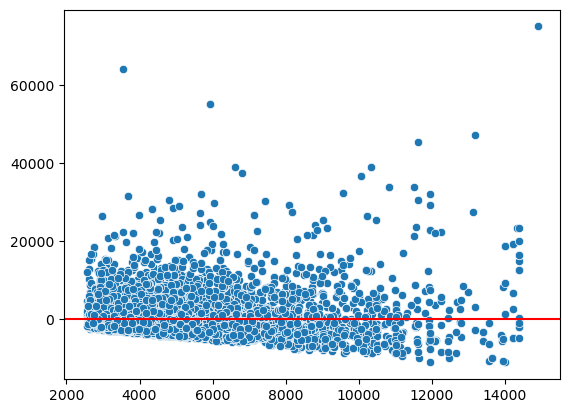


R² final: 0.15604670312784275


In [ ]:
print("\nResíduos modelo final")

sns.scatterplot(x=modelo_renda3.fittedvalues,
                y=modelo_renda3.resid)

plt.axhline(0,color='red')

plt.show()

print("\nR² final:", modelo_renda3.rsquared)

Resolvendo tarefa 03 - Exercicio 03 - item 5
5.Faça uma análise de resíduos. Avalie a qualidade do ajuste.
5.2. Análise escrita

REPOSTA: Análise dos resíduos e qualidade do modelo

O gráfico de resíduos versus valores ajustados mostra uma dispersão relativamente aleatória em torno da linha zero, o que indica que o modelo linear é razoavelmente adequado. No entanto, observa-se grande variabilidade dos resíduos, sugerindo que ainda existe variabilidade da renda não explicada pelas variáveis utilizadas.

O coeficiente de determinação R² ≈ 0,156 indica que o modelo explica cerca de 15,6% da variabilidade da renda, o que representa um poder explicativo baixo a moderado.

Além disso, os testes estatísticos dos resíduos (Omnibus e Jarque-Bera) sugerem que os resíduos não seguem perfeitamente a normalidade, indicando possíveis limitações no ajuste.

Conclusão:
O modelo apresenta ajuste estatisticamente válido, mas com capacidade explicativa limitada. Isso sugere que outras variáveis poderiam ser incluídas para melhorar a previsão da renda.